A notebook for describing and demonstrating the colour analysis of a spectral library at the Material Collection level.

In [1]:
%load_ext autoreload
%autoreload 2

# Overview

The Spectral Parameters Toolkit uses publicly available reflectance spectra of materials, and processes these with the expected spectral response of a given instrument.

However, in this notebook we use privately acquired reflectance spectra of the MacBeth ColorChecker reference standard, captured by collegeaus at Aberystwyth University.

We use the MacBeth ColorChecker, and publicly available online reference data to demonstrate sampling and conversion of the target to sRGB and other colour spaces using SPTK.

The steps are:

1. Create a new MaterialCollection object from the MacBeth ColorChecker spectral library (included in the example spectral library).
2. Produce a plot of the spectral library.
3. Produce a visualisation of the colours of the patches, as expected under D65 illumination.
4. Compare the rendered colours to those expected of the MacBeth ColorChecker, as provided by [BabelColour](https://babelcolor.com/colorchecker.htm).

# Creating a MaterialCollection Object <a id="creating"></a>

Here we will import the example_spectral_library into a new material collection object.

Our MacBeth ColorChecker data only extends to 1030 nm, so we need to change the limit:

In [2]:
import sptk.config as cfg

In [3]:
cfg.update_sample_res('wvl_max', 1030)

In [4]:
from sptk.material_collection import MaterialCollection

We will the MacBeth ColorChecker (MBCC), as well as the previously used example synthetic and natural red and green materials for comparison.

In [5]:
MATERIAL_SET = {
#     'Reds': [('synthetic_reds', '*'),
#             ('mineral_reds', '*')],
#     'Greens': [('synthetic_greens', '*')],
    'MacBeth ColorChecker': [('macbeth_colorchecker', '*')],}

We pass this material set to the MaterialCollection constructor function, below.

As part of the constructor call, we also specify the spectral library to use:

```spectral_library='example_spectral_library'```

and we define a ```project_name```.

In this example we have switched off the 'balance_classes' function, such that all files found in the example spectral library will be loaded here. 'balance_classes' randomly discards entries such that the sizes of the classes in the ```MATERIAL_SET``` are equal.

During execution, the constructor function also produces plots of the spectral library, that are displayed here.

Note that by default the construction process also saves the MaterialCollection DataFrame content to a csv file, and to a pickle format, for quick reloading and analysis by other projects.


In [6]:
PROJECT_NAME = 'sptk_colour_example'
matcol = MaterialCollection(
            materials=MATERIAL_SET,
            spectral_library='example_spectral_library',    
            plot_profiles=False,        
            project_name=PROJECT_NAME,
            balance_classes=False,
            load_existing=False) # save the output for later access

Building new sptk_colour_example MaterialCollection DF

macbeth_colorchecker: black.csv loaded
macbeth_colorchecker: blue.csv loaded
macbeth_colorchecker: blue_flower.csv loaded
macbeth_colorchecker: blue_sky.csv loaded
macbeth_colorchecker: bluish_green.csv loaded
macbeth_colorchecker: cyan.csv loaded
macbeth_colorchecker: dark_skin.csv loaded
macbeth_colorchecker: foliage.csv loaded
macbeth_colorchecker: green.csv loaded
macbeth_colorchecker: light_skin.csv loaded
macbeth_colorchecker: magenta.csv loaded
macbeth_colorchecker: moderate_red.csv loaded
macbeth_colorchecker: neutral_3.5.csv loaded
macbeth_colorchecker: neutral_5.csv loaded
macbeth_colorchecker: neutral_6.5.csv loaded
macbeth_colorchecker: neutral_8.csv loaded
macbeth_colorchecker: orange.csv loaded
macbeth_colorchecker: orange_yellow.csv loaded
macbeth_colorchecker: purple.csv loaded
macbeth_colorchecker: purplish_blue.csv loaded
macbeth_colorchecker: red.csv loaded
macbeth_colorchecker: white.csv loaded
macbeth_colorche

In [7]:
matcol.main_df

,Filepath,Category,Sample ID,Mineral Name,Sample Description,Date Added,Viewing Geometry,Other Information,Formula,Composition,...,1020.0,1021.0,1022.0,1023.0,1024.0,1025.0,1026.0,1027.0,1028.0,1029.0
Data ID,,,,,,,,,,,,,,,,,,,,,
black,spectral_library/example_spectral_library/macb...,MacBeth ColorChecker,black,macbeth_colorchecker,Macbeth ColorChecker Patch,14/06/2024,NaN,NaN,NaN,NaN,...,0.03816,0.047690,0.04957,0.058230,0.05256,0.050953,0.04297,0.038697,0.03965,0.069240
blue,spectral_library/example_spectral_library/macb...,MacBeth ColorChecker,blue,macbeth_colorchecker,Macbeth ColorChecker Patch,14/06/2024,NaN,NaN,NaN,NaN,...,0.55993,0.552885,0.55649,0.551050,0.56374,0.558077,0.56163,0.545510,0.53665,0.530293
blue_flower,spectral_library/example_spectral_library/macb...,MacBeth ColorChecker,blue_flower,macbeth_colorchecker,Macbeth ColorChecker Patch,14/06/2024,NaN,NaN,NaN,NaN,...,0.86240,0.865185,0.87919,0.883880,0.88503,0.879463,0.86791,0.864743,0.85910,0.839680
blue_sky,spectral_library/example_spectral_library/macb...,MacBeth ColorChecker,blue_sky,macbeth_colorchecker,Macbeth ColorChecker Patch,14/06/2024,NaN,NaN,NaN,NaN,...,0.86332,0.858680,0.85509,0.858710,0.85421,0.854053,0.83911,0.837017,0.82967,0.844043
bluish_green,spectral_library/example_spectral_library/macb...,MacBeth ColorChecker,bluish_green,macbeth_colorchecker,Macbeth ColorChecker Patch,14/06/2024,NaN,NaN,NaN,NaN,...,0.55952,0.558185,0.56511,0.568627,0.56732,0.557633,0.56157,0.562597,0.56370,0.556443
cyan,spectral_library/example_spectral_library/macb...,MacBeth ColorChecker,cyan,macbeth_colorchecker,Macbeth ColorChecker Patch,14/06/2024,NaN,NaN,NaN,NaN,...,0.60287,0.605835,0.58522,0.580997,0.58091,0.588983,0.58496,0.579230,0.57568,0.596740
dark_skin,spectral_library/example_spectral_library/macb...,MacBeth ColorChecker,dark_skin,macbeth_colorchecker,Macbeth ColorChecker Patch,14/06/2024,NaN,NaN,NaN,NaN,...,0.70301,0.702190,0.70758,0.704923,0.70802,0.701660,0.69806,0.682510,0.67401,0.684910
foliage,spectral_library/example_spectral_library/macb...,MacBeth ColorChecker,foliage,macbeth_colorchecker,Macbeth ColorChecker Patch,14/06/2024,NaN,NaN,NaN,NaN,...,0.14494,0.141610,0.14883,0.157973,0.16274,0.154380,0.14499,0.134843,0.13348,0.154170
green,spectral_library/example_spectral_library/macb...,MacBeth ColorChecker,green,macbeth_colorchecker,Macbeth ColorChecker Patch,14/06/2024,NaN,NaN,NaN,NaN,...,0.52268,0.519300,0.51888,0.507347,0.50590,0.512777,0.50956,0.504150,0.49386,0.484177


<AxesSubplot: xlabel='Wavelength (nm)', ylabel='Reflectance'>

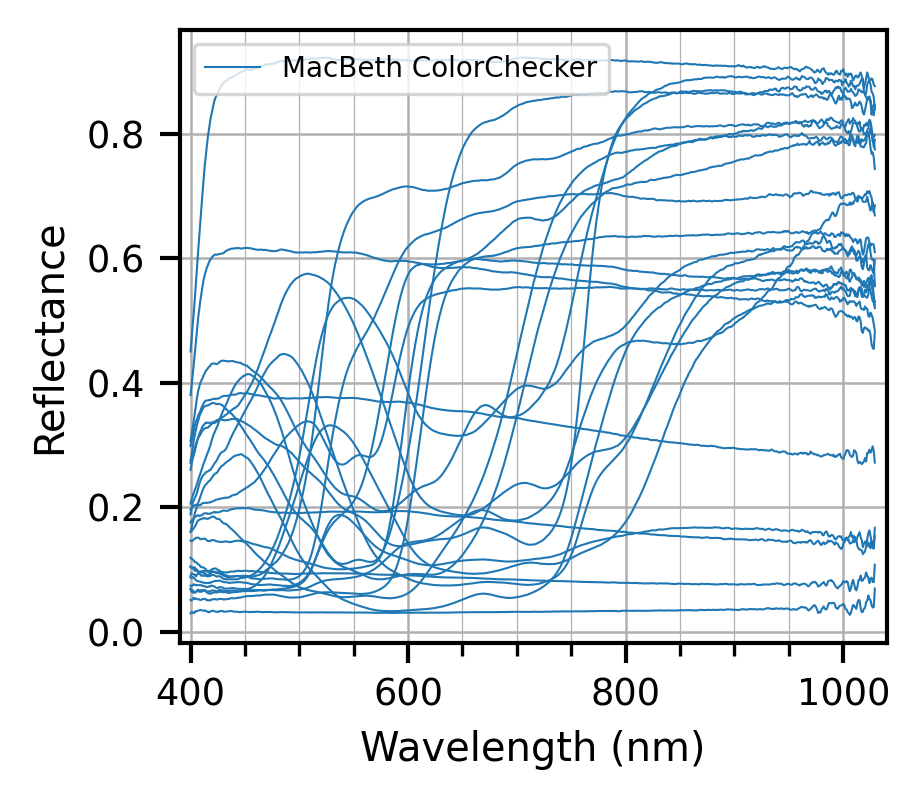

In [8]:
matcol.plot_profiles(categories_only=True)

[<AxesSubplot: xlabel='Wavelength (nm)', ylabel='Reflectance'>,
 <AxesSubplot: xlabel='Wavelength (nm)', ylabel='Reflectance'>]

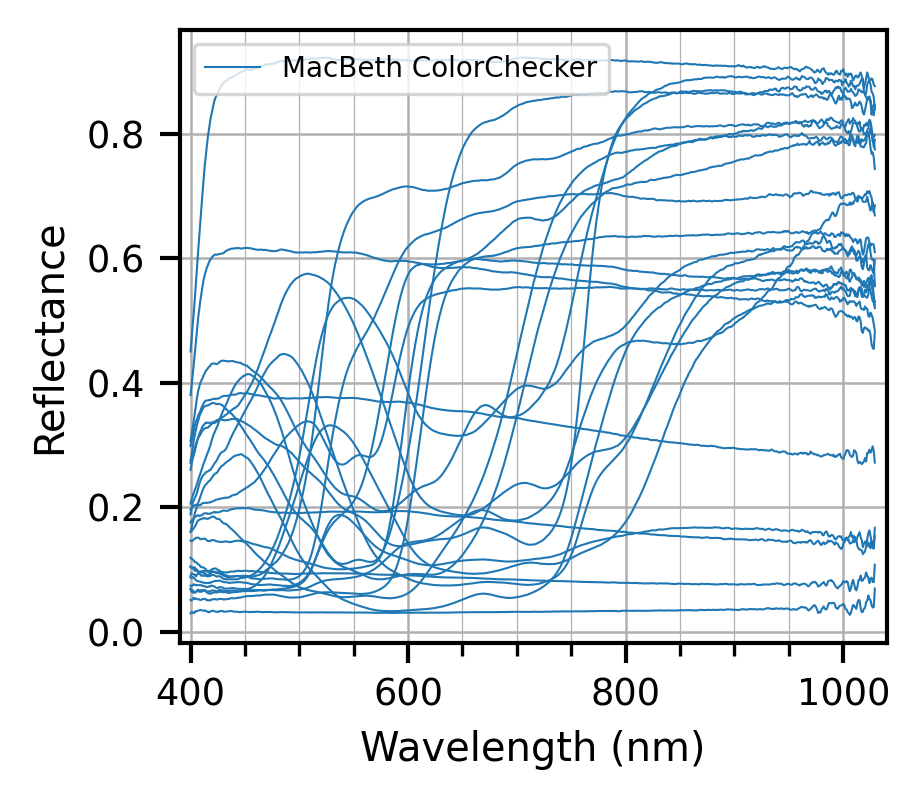

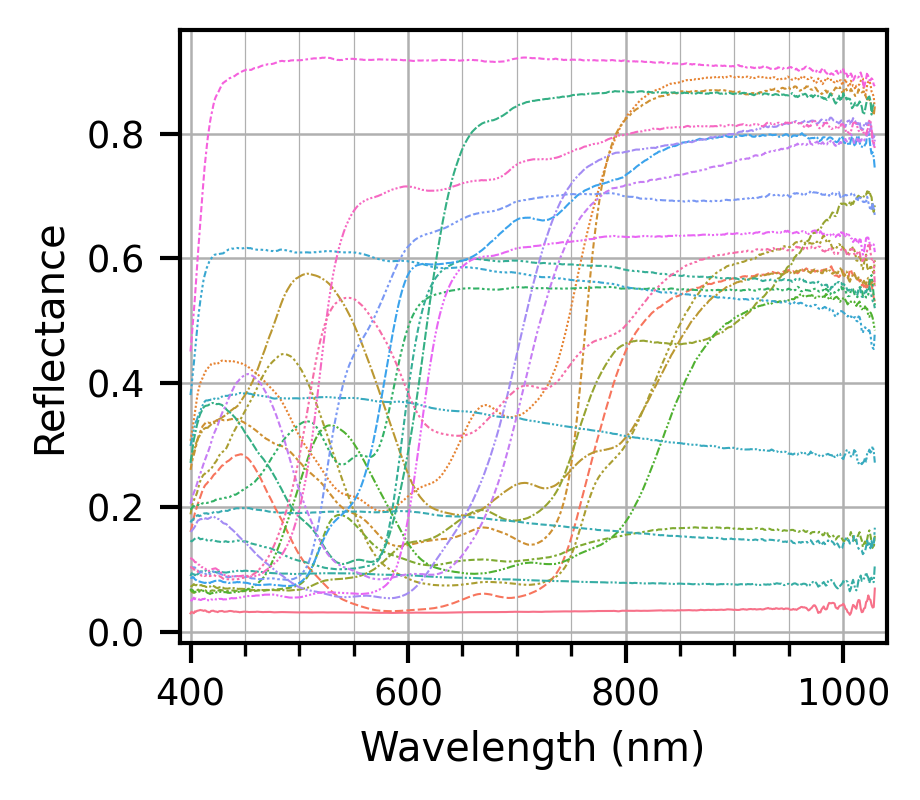

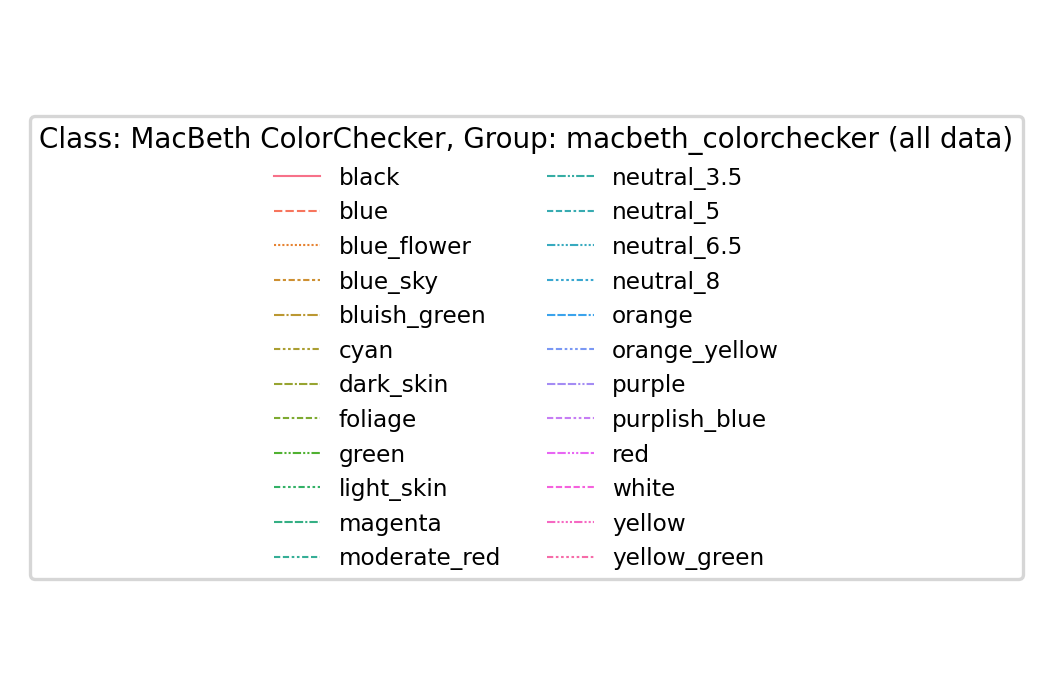

In [9]:
matcol.plot_profiles(categories_only=False)

The process of building the library includes resampling each entry to a common spectral range and resolution, that are set in the ```config.py``` file of sptk. In this example we have set the range to 400 -- 1000 nm, and the resolution to 1 nm.

We can check some properties of the loaded material collection, such as the number of entries in the classes, and the number of entries in each constituent material group of each class:

In [10]:
matcol.print_category_entries(print_minerals=True)

Samples in MacBeth ColorChecker class: 24
Unique sample sources in MacBeth ColorChecker class: 24
  Samples in macbeth_colorchecker mineral group: 24


# Balancing the mineral groups

We can perform balancing of the classes after the construction, by calling the ```balance_mineral_groups``` method.

In [11]:
matcol.balance_mineral_groups(random_state=0)

Balancing class sizes...


Printing the category entries allows us a quick-check of the new class sizes:

In [12]:
matcol.print_category_entries(print_minerals=True)

Samples in MacBeth ColorChecker class: 24
Unique sample sources in MacBeth ColorChecker class: 24
  Samples in macbeth_colorchecker mineral group: 24


and we can reproduce the plots of the relfectance profiles to visually inspect the new material collection:

[<AxesSubplot: xlabel='Wavelength (nm)', ylabel='Reflectance'>,
 <AxesSubplot: xlabel='Wavelength (nm)', ylabel='Reflectance'>]

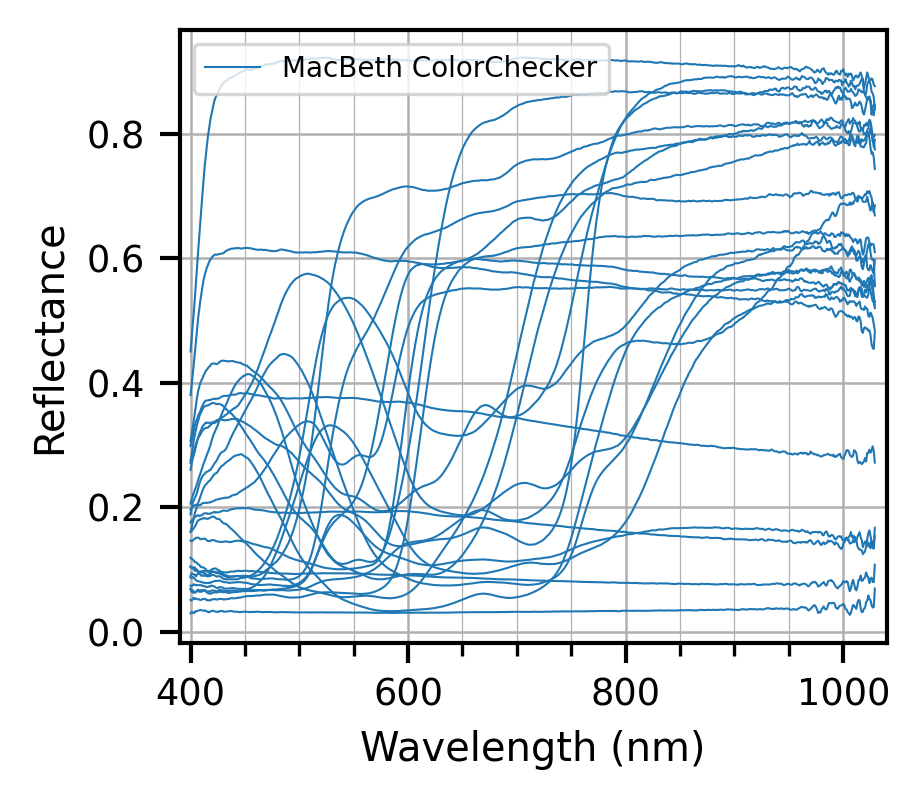

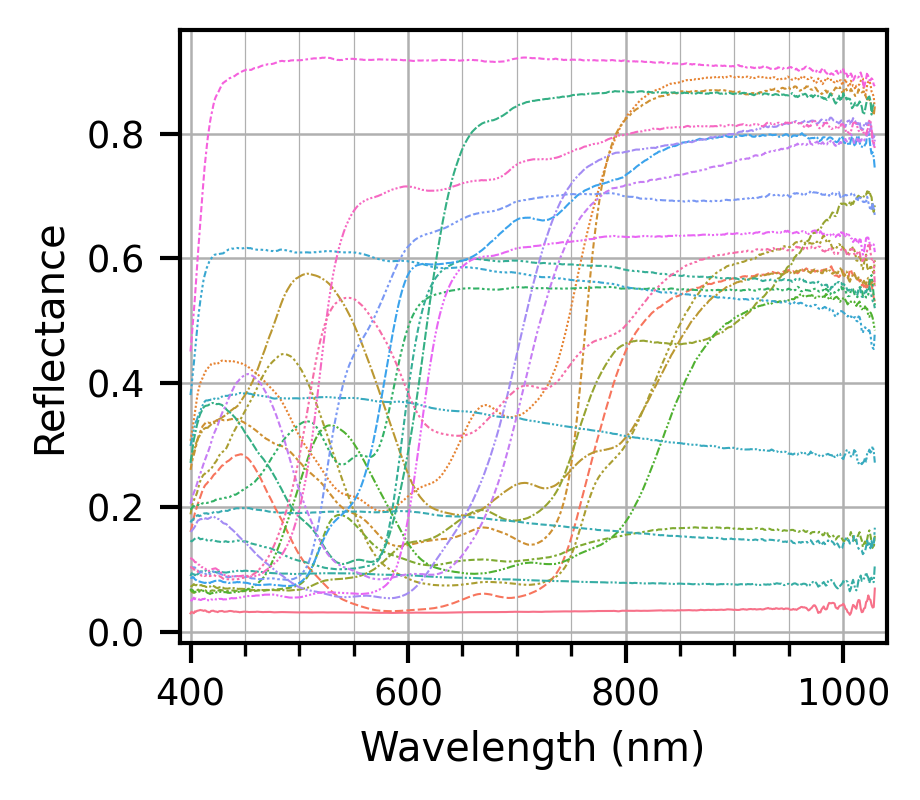

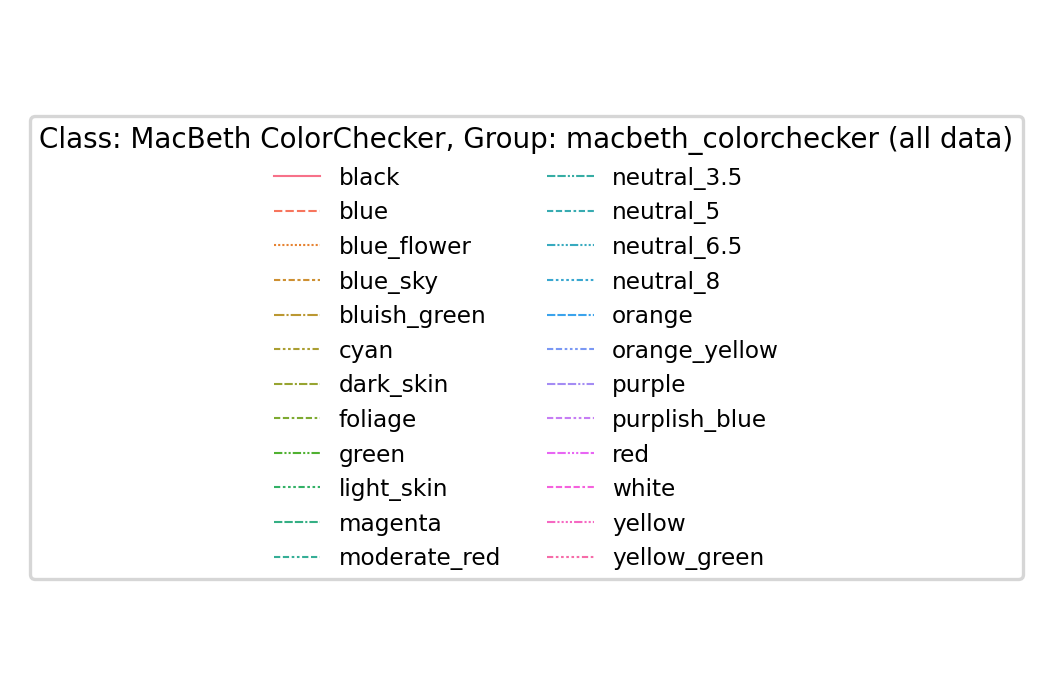

In [13]:
matcol.plot_profiles(categories_only=False)

As we have updated the content of the material collection, we overwrite the previously exported files with a new export:

In [14]:
matcol.export_main_df()

Exporting the Material Collection to CSV and Pickle formats...


The MaterialCollection object for the ```example_spectral_library``` project can now be loaded independently of this notebook. Indeed we will use it in subsequent example notebooks.

# Colour Rendering

TODO: write description of colour conversion process here.

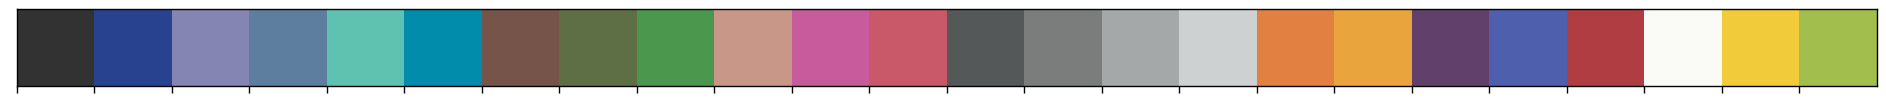

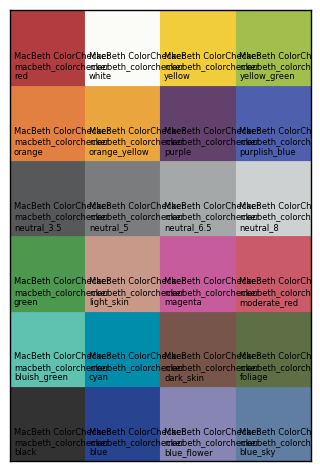

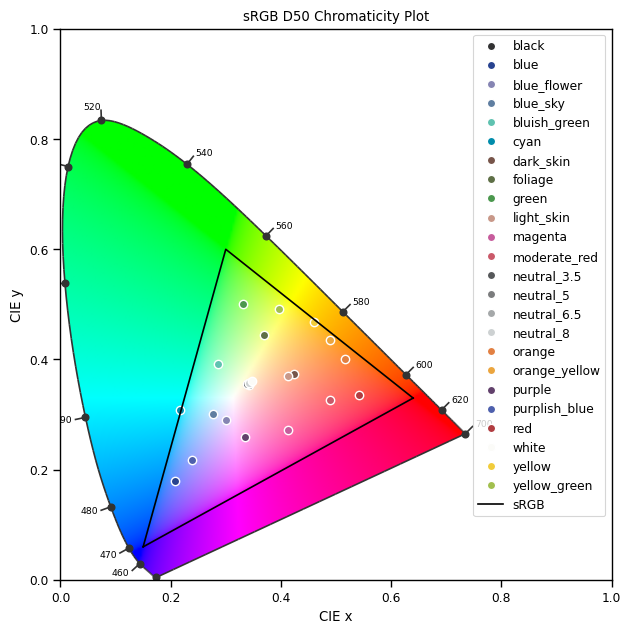

(<sptk.material_collection.MaterialCollection at 0x1543cca00>, None)

In [88]:
matcol.render_colour('D50')

For comparison, we can use the colour-science library to produce a visualisation of the expected values for the MacBeth ColorChecker:

In [18]:
import colour

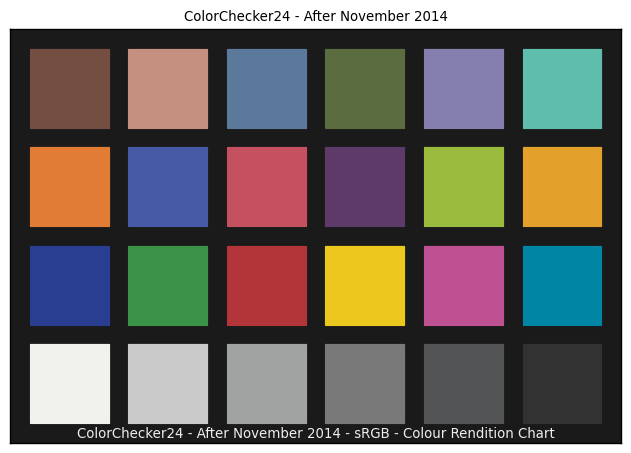

(<Figure size 640x480 with 1 Axes>,
 <AxesSubplot: title={'center': 'ColorChecker24 - After November 2014'}>)

In [28]:
colour.plotting.plot_single_colour_checker(
    colour_checker='ColorChecker24 - After November 2014', text_kwargs={"visible": False}
)